In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [ ]:
df=pd.read_csv('/content/Employee_Attrition_Dataset.csv')

In [ ]:
df.head()


,EmployeeID,Age,Department,Salary,Overtime,JobSatisfaction,DistanceFromHome_KM,YearsAtCompany,YearsSinceLastPromotion,WorkLifeBalance,ManagerRating,Attrition
0,1001,50,Research & Development,18090.0,No,Low,29,15,2,Good,Medium,Yes
1,1002,36,IT,13642.0,No,Medium,18,13,12,Poor,High,Yes
2,1003,29,Human Resources,7521.0,Yes,Very High,14,0,1,Best,Medium,No
3,1004,42,Sales,13638.0,No,Medium,25,7,7,Good,Low,Yes
4,1005,40,Research & Development,16730.0,No,High,15,16,3,Good,Medium,No


In [ ]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   EmployeeID               1500 non-null   int64  
 1   Age                      1500 non-null   int64  
 2   Department               1500 non-null   object 
 3   Salary                   1475 non-null   float64
 4   Overtime                 1500 non-null   object 
 5   JobSatisfaction          1480 non-null   object 
 6   DistanceFromHome_KM      1500 non-null   int64  
 7   YearsAtCompany           1500 non-null   int64  
 8   YearsSinceLastPromotion  1500 non-null   int64  
 9   WorkLifeBalance          1500 non-null   object 
 10  ManagerRating            1500 non-null   object 
 11  Attrition                1500 non-null   object 
dtypes: float64(1), int64(5), object(6)
memory usage: 140.8+ KB


In [ ]:

df.describe()


,EmployeeID,Age,Salary,DistanceFromHome_KM,YearsAtCompany,YearsSinceLastPromotion
count,1500.000000,1500.000000,1475.000000,1500.000000,1500.000000,1500.000000
mean,1750.500000,41.002667,12815.544407,14.978667,7.890000,4.038000
std,433.157015,11.062681,3519.781419,8.339979,5.925198,4.180774
min,1001.000000,22.000000,5384.000000,1.000000,0.000000,0.000000
25%,1375.750000,31.000000,10045.000000,8.000000,3.000000,1.000000
50%,1750.500000,42.000000,12846.000000,15.000000,7.000000,3.000000
75%,2125.250000,50.000000,15382.500000,22.000000,13.000000,6.000000
max,2500.000000,59.000000,21230.000000,29.000000,20.000000,19.000000


In [ ]:

df.shape


(1500, 12)

In [ ]:

df.columns


Index(['EmployeeID', 'Age', 'Department', 'Salary', 'Overtime',
       'JobSatisfaction', 'DistanceFromHome_KM', 'YearsAtCompany',
       'YearsSinceLastPromotion', 'WorkLifeBalance', 'ManagerRating',
       'Attrition'],
      dtype='object')

In [ ]:

df.isnull().sum()


,0
EmployeeID,0
Age,0
Department,0
Salary,25
Overtime,0
JobSatisfaction,20
DistanceFromHome_KM,0
YearsAtCompany,0
YearsSinceLastPromotion,0
WorkLifeBalance,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [ ]:
features = [
    'Age',
    'Department',
    'Salary',
    'YearsAtCompany',
    'YearsSinceLastPromotion',
    'WorkLifeBalance',
    'ManagerRating',
    'DistanceFromHome_KM',
    'JobSatisfaction',
    'Overtime'
]
X = df[features]
y = df["Attrition"]

In [ ]:
import joblib
joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.impute import SimpleImputer
lr = LogisticRegression(random_state=42)
imputer = SimpleImputer(strategy='mean')
X_train_s_imputed = imputer.fit_transform(X_train)
X_test_s_imputed = imputer.transform(X_test)
lr.fit(X_train_s_imputed, y_train)
y_pred_lr = lr.predict(X_test_s_imputed)
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))

Accuracy: 0.7066666666666667
              precision    recall  f1-score   support

           0       0.71      0.80      0.75       167
           1       0.70      0.59      0.64       133

    accuracy                           0.71       300
   macro avg       0.71      0.70      0.70       300
weighted avg       0.71      0.71      0.70       300

[[133  34]
 [ 54  79]]


In [ ]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(X_train_s_imputed, y_train)
y_pred_nb = nb.predict(X_test_s_imputed)
print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))
print(confusion_matrix(y_test, y_pred_nb))

Accuracy: 0.72
              precision    recall  f1-score   support

           0       0.72      0.82      0.77       167
           1       0.72      0.59      0.65       133

    accuracy                           0.72       300
   macro avg       0.72      0.71      0.71       300
weighted avg       0.72      0.72      0.72       300

[[137  30]
 [ 54  79]]


In [ ]:
from sklearn.svm import SVC
svm = SVC(random_state=42)
svm.fit(X_train_s_imputed, y_train)
y_pred_svm = svm.predict(X_test_s_imputed)
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))
print(confusion_matrix(y_test, y_pred_svm))

Accuracy: 0.7366666666666667
              precision    recall  f1-score   support

           0       0.73      0.83      0.78       167
           1       0.75      0.62      0.67       133

    accuracy                           0.74       300
   macro avg       0.74      0.72      0.73       300
weighted avg       0.74      0.74      0.73       300

[[139  28]
 [ 51  82]]


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_s_imputed, y_train)
y_pred_knn = knn.predict(X_test_s_imputed)
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))
print(confusion_matrix(y_test, y_pred_knn))

Accuracy: 0.7033333333333334
              precision    recall  f1-score   support

           0       0.71      0.78      0.74       167
           1       0.69      0.61      0.65       133

    accuracy                           0.70       300
   macro avg       0.70      0.69      0.70       300
weighted avg       0.70      0.70      0.70       300

[[130  37]
 [ 52  81]]


In [ ]:
models = ['Logistic Regression', 'Naive Bayes', 'SVM', 'KNN']
accuracies = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_nb),
    accuracy_score(y_test, y_pred_svm),
    accuracy_score(y_test, y_pred_knn)
]
result = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracies
})

print(result)

                 Model  Accuracy
0  Logistic Regression  0.706667
1          Naive Bayes  0.720000
2                  SVM  0.736667
3                  KNN  0.703333


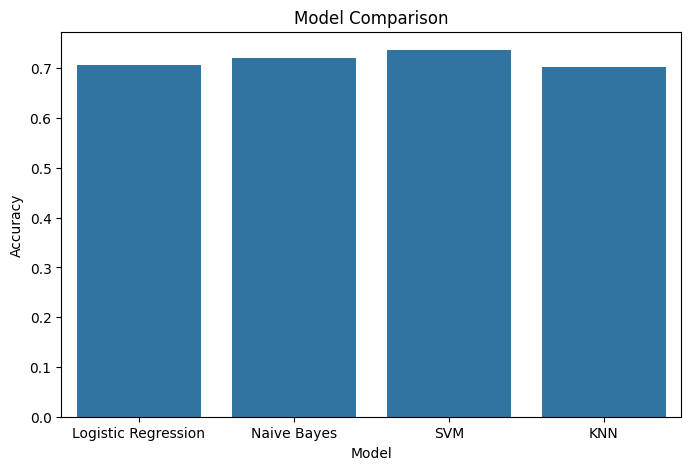

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x='Model', y='Accuracy', data=result)
plt.title("Model Comparison")
plt.show()

In [ ]:
import joblib
joblib.dump(svm, "employee_attrition_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']